# 🏠 House Price Prediction Project
End-to-end Machine Learning pipeline for predicting real estate prices.

## 📦 1. Import Libraries

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import re

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

## 📊 2. Exploratory Data Analysis (EDA)

In [ ]:
df = pd.read_csv('/content/house_prices.csv')
df.head()

,Index,Title,Description,Amount(in rupees),Price (in rupees),location,Carpet Area,Status,Floor,Transaction,...,facing,overlooking,Society,Bathroom,Balcony,Car Parking,Ownership,Super Area,Dimensions,Plot Area
0,0,1 BHK Ready to Occupy Flat for sale in Srushti...,"Bhiwandi, Thane has an attractive 1 BHK Flat f...",42 Lac,6000.0,thane,500 sqft,Ready to Move,10 out of 11,Resale,...,NaN,NaN,Srushti Siddhi Mangal Murti Complex,1,2,NaN,NaN,NaN,NaN,NaN
1,1,2 BHK Ready to Occupy Flat for sale in Dosti V...,One can find this stunning 2 BHK flat for sale...,98 Lac,13799.0,thane,473 sqft,Ready to Move,3 out of 22,Resale,...,East,Garden/Park,Dosti Vihar,2,NaN,1 Open,Freehold,NaN,NaN,NaN
2,2,2 BHK Ready to Occupy Flat for sale in Sunrise...,Up for immediate sale is a 2 BHK apartment in ...,1.40 Cr,17500.0,thane,779 sqft,Ready to Move,10 out of 29,Resale,...,East,Garden/Park,Sunrise by Kalpataru,2,NaN,1 Covered,Freehold,NaN,NaN,NaN
3,3,1 BHK Ready to Occupy Flat for sale Kasheli,This beautiful 1 BHK Flat is available for sal...,25 Lac,NaN,thane,530 sqft,Ready to Move,1 out of 3,Resale,...,NaN,NaN,NaN,1,1,NaN,NaN,NaN,NaN,NaN
4,4,2 BHK Ready to Occupy Flat for sale in TenX Ha...,"This lovely 2 BHK Flat in Pokhran Road, Thane ...",1.60 Cr,18824.0,thane,635 sqft,Ready to Move,20 out of 42,Resale,...,West,"Garden/Park, Main Road",TenX Habitat Raymond Realty,2,NaN,1 Covered,Co-operative Society,NaN,NaN,NaN


In [ ]:
df.shape

(5313, 21)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5313 entries, 0 to 5312
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Index              5313 non-null   int64  
 1   Title              5313 non-null   object 
 2   Description        5219 non-null   object 
 3   Amount(in rupees)  5313 non-null   object 
 4   Price (in rupees)  4833 non-null   float64
 5   location           5313 non-null   object 
 6   Carpet Area        3213 non-null   object 
 7   Status             5295 non-null   object 
 8   Floor              5142 non-null   object 
 9   Transaction        5305 non-null   object 
 10  Furnishing         5234 non-null   object 
 11  facing             3197 non-null   object 
 12  overlooking        3131 non-null   object 
 13  Society            3503 non-null   object 
 14  Bathroom           5285 non-null   object 
 15  Balcony            3157 non-null   object 
 16  Car Parking        2355 

In [ ]:
df.describe()

,Index,Price (in rupees),Dimensions,Plot Area
count,5313.000000,4833.000000,0.0,0.0
mean,2656.000000,9843.703911,NaN,NaN
std,1533.875321,8994.135754,NaN,NaN
min,0.000000,1583.000000,NaN,NaN
25%,1328.000000,4527.000000,NaN,NaN
50%,2656.000000,6486.000000,NaN,NaN
75%,3984.000000,11429.000000,NaN,NaN
max,5312.000000,84619.000000,NaN,NaN


In [ ]:
df.isnull().mean().sort_values(ascending=False)

,0
Plot Area,1.000000
Dimensions,1.000000
Super Area,0.605496
Car Parking,0.556748
overlooking,0.410691
Balcony,0.405797
facing,0.398268
Carpet Area,0.395257
Ownership,0.372671
Society,0.340674


#There are 5313 rows

#Index , Price (in rupees) ,Dimensions & Plot Area are the numeric columns and others are text

#Dimensions & Plot Area have the most null valuse


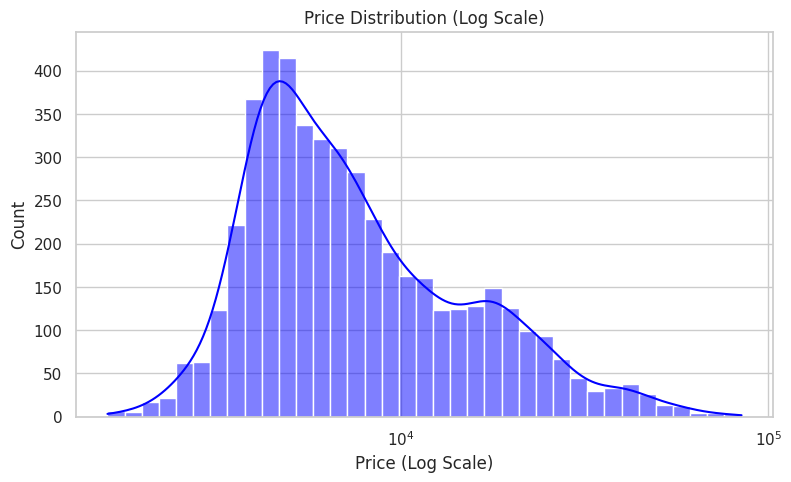

In [ ]:
sns.set_theme(style="whitegrid")

# 1. Distribution of the target price (Log scale because data is heavily skewed)
plt.figure(figsize=(9, 5))
sns.histplot(df["Price (in rupees)"], kde=True, log_scale=True, color="blue")
plt.title("Price Distribution (Log Scale)")
plt.xlabel("Price (Log Scale)")
plt.ylabel("Count")
plt.show()

### Price Distribution
* **Observation:** The price distribution is heavily right-skewed, meaning most properties have lower prices while a few luxury listings have extremely high values.
* **Solution:** Applying a log scale helps normalize the distribution, making it suitable for machine learning models.

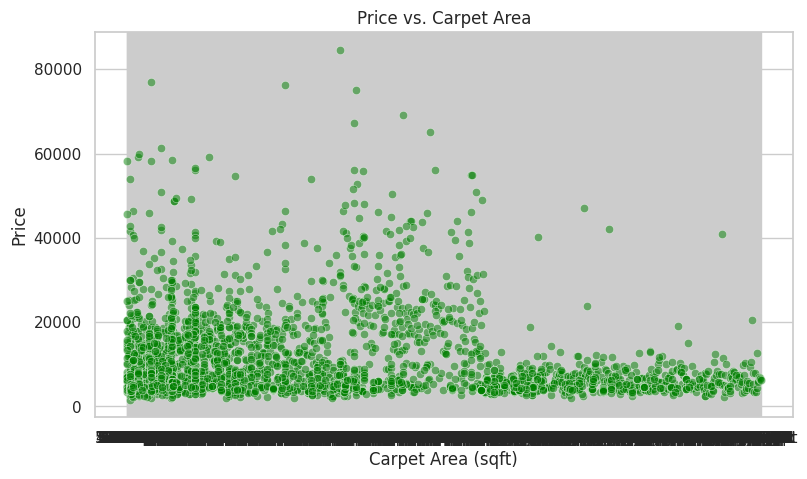

In [ ]:
# 2. Price vs. carpet area (Scatter plot)
plt.figure(figsize=(9, 5))
sns.scatterplot(x=df["Carpet Area"], y=df["Price (in rupees)"], alpha=0.5, color="green")
plt.title("Price vs. Carpet Area")
plt.xlabel("Carpet Area (sqft)")
plt.ylabel("Price")
plt.show()

### Price vs. Carpet Area
* **Observation:** There is a general positive correlation between the property price and its carpet area.
* **Note:** Some outlier points show high prices with smaller areas or vice versa, which will need handling during the data cleaning phase.

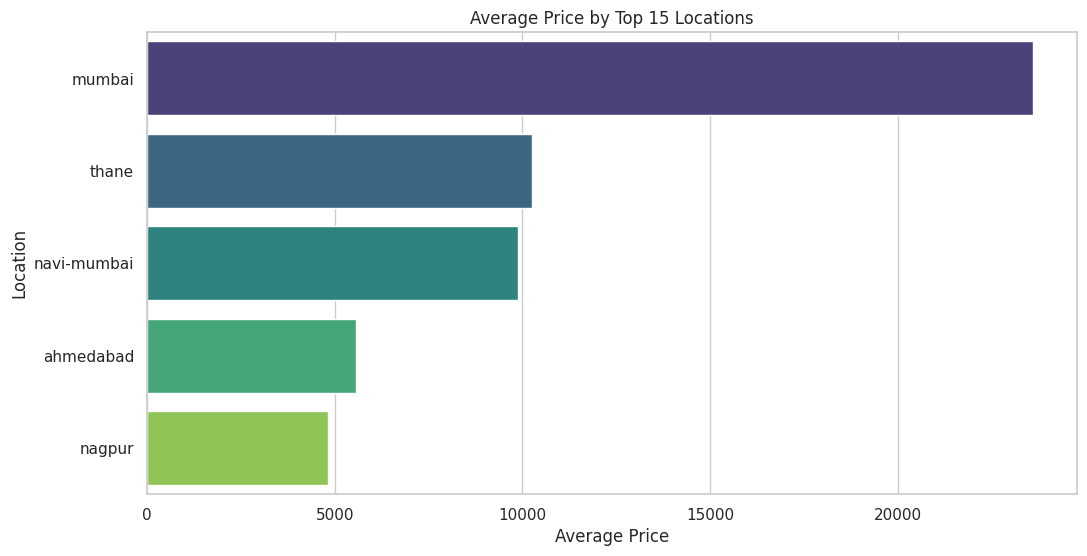

In [ ]:
# 3. Average price by top-15 locations (Bar chart)
plt.figure(figsize=(12, 6))
top_15_locs = df.groupby("location")["Price (in rupees)"].mean().nlargest(15)
sns.barplot(x=top_15_locs.values, y=top_15_locs.index, palette="viridis")
plt.title("Average Price by Top 15 Locations")
plt.xlabel("Average Price")
plt.ylabel("Location")
plt.show()

### Average Price by Top Locations
* **Observation:** Major metropolitan areas like Mumbai and Thane show significantly higher average property prices compared to other regions.
* **Importance:** Location plays a critical role in predicting property prices, making location grouping essential for feature engineering.

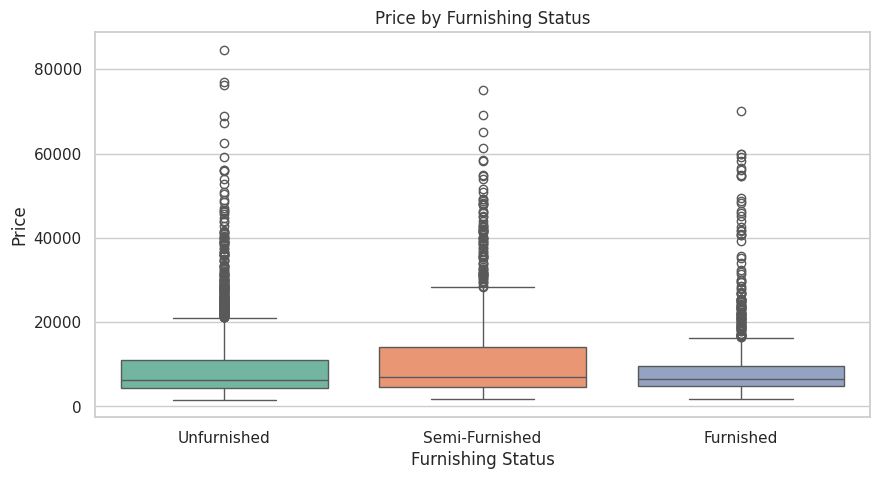

In [ ]:
# 4. Price by furnishing status (Box plots)
plt.figure(figsize=(10, 5))
sns.boxplot(x=df["Furnishing"], y=df["Price (in rupees)"], palette="Set2")
plt.title("Price by Furnishing Status")
plt.xlabel("Furnishing Status")
plt.ylabel("Price")
plt.show()

### Price by Furnishing Status
* **Observation:** The box plot compares the price variations across different furnishing statuses (Unfurnished, Semi-Furnished, Furnished).
* **Insight:** Semi-furnished and furnished properties display a wider range of high-end price outliers compared to unfurnished ones.

## 🧹 3. Data Preprocessing & Feature Engineering

In [ ]:


# 1. Parse Amount (in rupees) text into numeric values
def parse_amount(x):
    if not isinstance(x, str):
        return None
    x = x.strip().lower()
    try:
        if "lac" in x:
            return float(x.replace("lac", "").strip()) * 1e5
        if "cr" in x:
            return float(x.replace("cr", "").strip()) * 1e7
        return float(x.replace(",", ""))
    except ValueError:
        return None

df["Price_clean"] = df["Amount(in rupees)"].apply(parse_amount)
df = df.dropna(subset=["Price_clean"])

In [ ]:
# 2. Extract and normalize Carpet Area to sqft
def parse_area(x):
    if not isinstance(x, str):
        return np.nan
    x = x.lower().strip()
    match = re.search(r'([\d,]+\.?\d*)', x)
    if not match:
        return np.nan
    val = float(match.group(1).replace(",", ""))
    if "sqm" in x or "sq. m" in x:
        return val * 10.764
    return val

df["carpet_area_sqft"] = df["Carpet Area"].apply(parse_area)


In [ ]:
# 3. Extract Floor Number
def parse_floor(x):
    if not isinstance(x, str):
        return np.nan
    x = x.lower().strip()
    if "ground" in x:
        return 0
    if "basement" in x:
        return -1
    match = re.search(r'(\d+)', x)
    return float(match.group(1)) if match else np.nan

df["floor_num"] = df["Floor"].apply(parse_floor)

In [ ]:
# 4. Convert Bathroom and Balcony to numeric
df["bathroom"] = pd.to_numeric(df["Bathroom"], errors="coerce")
df["balcony"] = pd.to_numeric(df["Balcony"], errors="coerce")

In [ ]:
# 5. Handle high-cardinality for location
top_locations = df['location'].value_counts().nlargest(50).index.tolist()
df['location_grouped'] = df['location'].apply(lambda x: x if x in top_locations else 'other')

In [ ]:
# 6. Define feature lists using exact column names
numeric_features = ["carpet_area_sqft", "floor_num", "bathroom", "balcony"]
categorical_features = ["location_grouped", "Furnishing", "Transaction", "Ownership", "facing"]

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5077 entries, 0 to 5312
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Amount(in rupees)  5077 non-null   object 
 1   location           5077 non-null   object 
 2   Carpet Area        3103 non-null   object 
 3   Status             5061 non-null   object 
 4   Floor              4914 non-null   object 
 5   Transaction        5070 non-null   object 
 6   Furnishing         5005 non-null   object 
 7   facing             3112 non-null   object 
 8   Bathroom           5051 non-null   object 
 9   Balcony            3032 non-null   object 
 10  Ownership          3241 non-null   object 
 11  Dimensions         0 non-null      float64
 12  Price_clean        5077 non-null   float64
 13  carpet_area_sqft   3103 non-null   float64
 14  floor_num          4914 non-null   float64
 15  bathroom           5049 non-null   float64
 16  balcony            3029 non-n

In [ ]:
df.isnull().sum()

,0
Amount(in rupees),0
location,0
Carpet Area,1974
Status,16
Floor,163
Transaction,7
Furnishing,72
facing,1965
Bathroom,26
Balcony,2045


In [ ]:
# 1. Drop columns that have too many missing values or are useless for our model
columns_to_drop = [
    'Index', 'Title', 'Description', 'Price (in rupees)','Dimensions',
    'Super Area', 'Plot Area', 'Car Parking', 'overlooking', 'Society'
]
df = df.drop(columns=[col for col in columns_to_drop if col in df.columns], errors='ignore')

# 2. Drop rows where critical essential features are missing (like price or main carpet area)
df = df.dropna(subset=['Price_clean', 'carpet_area_sqft'])

# 3. Handle missing values for remaining important columns:
# - Fill numerical columns with median
num_cols_to_fill = ['floor_num', 'bathroom', 'balcony']
for col in num_cols_to_fill:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].median())

# - Fill categorical/text columns with the most frequent value (Mode)
cat_cols_to_fill = ['Status', 'Floor', 'Transaction', 'Furnishing', 'facing', 'Ownership']
for col in cat_cols_to_fill:
    if col in df.columns and df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].mode()[0])

df["price_per_sqft"] = df["Price_clean"] / df["carpet_area_sqft"]
q1 = df["price_per_sqft"].quantile(0.01)
q99 = df["price_per_sqft"].quantile(0.99)
df = df[(df["price_per_sqft"] >= q1) & (df["price_per_sqft"] <= q99)]


# Verify that all missing values are handled
print("--- Missing values after cleaning ---")
print(df.isnull().sum())

--- Missing values after cleaning ---
Amount(in rupees)    0
location             0
Carpet Area          0
Status               0
Floor                0
Transaction          0
Furnishing           0
facing               0
Bathroom             0
Balcony              0
Ownership            0
Price_clean          0
carpet_area_sqft     0
floor_num            0
bathroom             0
balcony              0
location_grouped     0
price_per_sqft       0
dtype: int64


In [ ]:
# 1. Drop Dimensions column correctly
if 'Dimensions' in df.columns:
    df = df.drop(columns=['Dimensions'])

# 2. Directly fill any remaining missing values in the original Bathroom and Balcony columns
if 'Bathroom' in df.columns:
    df['Bathroom'] = df['Bathroom'].fillna(df['Bathroom'].mode()[0])

if 'Balcony' in df.columns:
    df['Balcony'] = df['Balcony'].fillna(0)

# 3. Final verification of missing values
print("--- Missing values after final fix ---")
print(df.isnull().sum())

--- Missing values after final fix ---
Amount(in rupees)    0
location             0
Carpet Area          0
Status               0
Floor                0
Transaction          0
Furnishing           0
facing               0
Bathroom             0
Balcony              0
Ownership            0
Price_clean          0
carpet_area_sqft     0
floor_num            0
bathroom             0
balcony              0
location_grouped     0
price_per_sqft       0
dtype: int64


In [ ]:
# 1. Define feature lists matching our cleaned columns
numeric_features = ["carpet_area_sqft", "floor_num", "bathroom", "balcony"]
categorical_features = ["location_grouped", "Furnishing", "Transaction", "Ownership", "facing"]

In [ ]:
# 2. Build Preprocessor Pipeline
preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler())
    ]), numeric_features),
    ("cat", Pipeline([
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]), categorical_features)
])

X = df[numeric_features + categorical_features]
y = df["Price_clean"]

## 🤖 4. Model Training & Evaluation

In [ ]:
# 3. Train/Test Split (80% training, 20% testing)[span_1](start_span)[span_1](end_span)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# 1. Linear Regression[span_11](start_span)[span_11](end_span)
lr_model = Pipeline([("prep", preprocessor), ("reg", LinearRegression())])
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)

print("--- 1. Linear Regression Performance ---")
print("MAE:", mean_absolute_error(y_test, lr_pred))
print("RMSE:", root_mean_squared_error(y_test, lr_pred))
print("R²:", r2_score(y_test, lr_pred))

--- 1. Linear Regression Performance ---
MAE: 7995284.847970202
RMSE: 14959686.534758195
R²: 0.6163285180420481


In [ ]:
# 2. Ridge Regression[span_12](start_span)[span_12](end_span)
ridge_model = Pipeline([("prep", preprocessor), ("reg", Ridge(alpha=1.0))])
ridge_model.fit(X_train, y_train)
ridge_pred = ridge_model.predict(X_test)

print("\n--- 2. Ridge Regression Performance ---")
print("MAE:", mean_absolute_error(y_test, ridge_pred))
print("RMSE:", root_mean_squared_error(y_test, ridge_pred))
print("R²:", r2_score(y_test, ridge_pred))


--- 2. Ridge Regression Performance ---
MAE: 7987061.562846887
RMSE: 14956782.029745692
R²: 0.6164774874150143


In [ ]:
# 3. Random Forest Regressor[span_13](start_span)[span_13](end_span)
rf_model = Pipeline([("prep", preprocessor), ("reg", RandomForestRegressor(n_estimators=200, random_state=42))])
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

print("\n--- 3. Random Forest Performance ---")
print("MAE:", mean_absolute_error(y_test, rf_pred))
print("RMSE:", root_mean_squared_error(y_test, rf_pred))
print("R²:", r2_score(y_test, rf_pred))


--- 3. Random Forest Performance ---
MAE: 4572825.387053097
RMSE: 11334678.860991154
R²: 0.7797413501285185


In [ ]:
# EXPORT THE BEST MODEL

import joblib
import json
import sklearn


joblib.dump(rf_model, "house_price.pkl")
print("Best model (Random Forest) saved as 'house_price.pkl'")


json.dump(sorted(df["location_grouped"].unique().tolist()), open("locations.json", "w"))
print("Locations saved as 'locations.json'")

print("Scikit-learn version:", sklearn.__version__)

Best model (Random Forest) saved as 'house_price.pkl'
Locations saved as 'locations.json'
Scikit-learn version: 1.6.1
